# 🤖 AI Agent for Parkinson's Disease Drug Discovery

This notebook provides an intelligent agent system for discovering and analyzing drug candidates for Parkinson's disease.

## Features:
- 🔍 **Smart Search**: Find drugs and targets by multiple criteria
- 📊 **Priority Analysis**: Identify high-priority targets based on disease relevance
- 🎯 **Binding Affinity Analysis**: Analyze predicted binding affinities from existing predictions
- 💡 **Recommendations**: Get AI-powered suggestions for drug candidates
- 📈 **Visualization**: Interactive plots and analysis
- 💾 **Export Results**: Save findings for further analysis
- 🤖 **LLM-Powered Analysis**: Use OpenAI to understand queries and generate intelligent summaries
- 🌐 **Online Research**: Combine data with public resources for comprehensive analysis

**Note**: This agent uses pre-computed binding affinity predictions from `pkd_drug_candidates_predictions.csv`.

In [44]:
# Core imports
import pandas as pd
import numpy as np
import os
from pathlib import Path
from typing import List, Dict, Optional, Tuple
from datetime import datetime
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# LLM and Web Search
try:
    from openai import OpenAI
    OPENAI_AVAILABLE = True
except ImportError:
    OPENAI_AVAILABLE = False
    print("⚠️  OpenAI library not installed. Install with: pip install openai")

try:
    import requests
    from urllib.parse import quote
    REQUESTS_AVAILABLE = True
except ImportError:
    REQUESTS_AVAILABLE = False
    print("⚠️  Requests library not installed. Install with: pip install requests")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 🧠 Drug Discovery Agent Class

In [45]:
class ParkinsonsDrugDiscoveryAgent:
    """
    AI Agent for Parkinson's Disease Drug Discovery
    
    This agent provides intelligent drug discovery capabilities including:
    - Loading and managing drug and target data
    - Priority-based target filtering
    - Binding affinity analysis from pre-computed predictions
    - Smart search and filtering
    - Recommendation generation
    
    Note: This agent uses pre-computed binding affinity predictions from 
    pkd_drug_candidates_predictions.csv rather than generating new predictions.
    """
    
    def __init__(self, data_dir: str = "./", openai_api_key: Optional[str] = None):
        """Initialize the agent with data directory and optional OpenAI API key."""
        self.data_dir = Path(data_dir)
        self.drug_df = None
        self.target_priority_df = None
        self.known_interactions = None
        self.predictions_df = None
        
        # LLM setup
        self.openai_client = None
        if openai_api_key:
            if OPENAI_AVAILABLE:
                self.openai_client = OpenAI(api_key=openai_api_key)
                print("✅ OpenAI client initialized")
            else:
                print("⚠️  OpenAI library not available. Install with: pip install openai")
        elif os.getenv("OPENAI_API_KEY"):
            if OPENAI_AVAILABLE:
                self.openai_client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
                print("✅ OpenAI client initialized from environment variable")
            else:
                print("⚠️  OpenAI library not available. Install with: pip install openai")
        else:
            print("ℹ️  OpenAI API key not provided. LLM features will be disabled.")
            print("   Set OPENAI_API_KEY environment variable or pass openai_api_key parameter")
        
        print("🤖 ParkinsonsDrugDiscoveryAgent initialized!")
    
    def load_data(self):
        """Load all required datasets."""
        print("📂 Loading datasets...")
        
        try:
            # Load drug data
            drug_path = self.data_dir / "drug_df_1101.csv"
            if drug_path.exists():
                self.drug_df = pd.read_csv(drug_path)
                print(f"  ✅ Loaded {len(self.drug_df)} drugs from drug_df_1101.csv")
            else:
                print(f"  ⚠️  Drug file not found: {drug_path}")
            
            # Load target priority data
            target_path = self.data_dir / "target_priority_gene_pd.csv"
            if target_path.exists():
                self.target_priority_df = pd.read_csv(target_path)
                print(f"  ✅ Loaded {len(self.target_priority_df)} targets from target_priority_gene_pd.csv")
            else:
                print(f"  ⚠️  Target priority file not found: {target_path}")
            
            # Load known drug-target interactions
            known_path = self.data_dir / "known_drug_pkd_target.csv"
            if known_path.exists():
                self.known_interactions = pd.read_csv(known_path)
                print(f"  ✅ Loaded {len(self.known_interactions)} known interactions")
            else:
                print(f"  ⚠️  Known interactions file not found: {known_path}")
            
            # Load binding affinity predictions (required for analysis)
            pred_path = self.data_dir / "pkd_drug_candidates_predictions.csv"
            if pred_path.exists():
                self.predictions_df = pd.read_csv(pred_path)
                print(f"  ✅ Loaded {len(self.predictions_df)} predictions from pkd_drug_candidates_predictions.csv")
                if 'Predicted_Affinity' in self.predictions_df.columns:
                    print(f"     Mean affinity: {self.predictions_df['Predicted_Affinity'].mean():.4f}")
            else:
                print(f"  ⚠️  Predictions file not found: {pred_path}")
                print(f"     Predictions are required for affinity analysis. Please ensure the file exists.")
            
            print("\n📊 Data Summary:")
            if self.drug_df is not None:
                print(f"  - Drugs: {len(self.drug_df)}")
            if self.target_priority_df is not None:
                print(f"  - Targets: {len(self.target_priority_df)}")
            if self.known_interactions is not None:
                print(f"  - Known interactions: {len(self.known_interactions)}")
            if self.predictions_df is not None:
                print(f"  - Predictions: {len(self.predictions_df)}")
            
        except Exception as e:
            print(f"❌ Error loading data: {e}")
            import traceback
            traceback.print_exc()
    
    def get_high_priority_targets(self, min_priority: float = 0.7, min_score: float = None):
        """Get high-priority targets for Parkinson's disease."""
        if self.target_priority_df is None:
            print("❌ Target priority data not loaded. Call load_data() first.")
            return None
        
        # Calculate priority if not present
        if 'priority' not in self.target_priority_df.columns:
            # Simple priority calculation based on score and other factors
            if 'score' in self.target_priority_df.columns:
                self.target_priority_df['priority'] = self.target_priority_df['score']
            else:
                print("⚠️  Priority column not found. Using score column.")
                return None
        
        # Filter by priority
        filtered = self.target_priority_df[self.target_priority_df['priority'] >= min_priority].copy()
        
        # Filter by score if specified
        if min_score is not None and 'score' in filtered.columns:
            filtered = filtered[filtered['score'] >= min_score]
        
        # Remove duplicates by Gene
        filtered = filtered.sort_values('priority', ascending=False).drop_duplicates(subset=['Gene'], keep='first')
        
        print(f"🎯 Found {len(filtered)} high-priority targets (priority >= {min_priority})")
        return filtered.reset_index(drop=True)
    
    def search_drugs(self, 
                    drug_name: Optional[str] = None,
                    chem_id: Optional[str] = None,
                    is_approved: Optional[bool] = None,
                    min_trial_phase: Optional[float] = None,
                    limit: int = 100) -> pd.DataFrame:
        """Search for drugs by various criteria."""
        if self.drug_df is None:
            print("❌ Drug data not loaded. Call load_data() first.")
            return pd.DataFrame()
        
        result = self.drug_df.copy()
        
        # Apply filters
        if drug_name:
            result = result[result['Drug Name'].str.contains(drug_name, case=False, na=False)]
        
        if chem_id:
            result = result[result['Chem ID'].str.contains(chem_id, case=False, na=False)]
        
        if is_approved is not None:
            if 'isApproved' in result.columns:
                result = result[result['isApproved'] == is_approved]
        
        if min_trial_phase is not None:
            if 'maximumClinicalTrialPhase' in result.columns:
                result = result[result['maximumClinicalTrialPhase'] >= min_trial_phase]
        
        result = result.head(limit)
        print(f"🔍 Found {len(result)} drugs matching criteria")
        return result.reset_index(drop=True)
    
    def search_targets(self, 
                      gene_name: Optional[str] = None,
                      target_id: Optional[str] = None,
                      min_priority: Optional[float] = None,
                      target_class: Optional[str] = None,
                      limit: int = 100) -> pd.DataFrame:
        """Search for targets by various criteria."""
        if self.target_priority_df is None:
            print("❌ Target data not loaded. Call load_data() first.")
            return pd.DataFrame()
        
        result = self.target_priority_df.copy()
        
        # Apply filters
        if gene_name:
            result = result[result['Gene'].str.contains(gene_name, case=False, na=False)]
        
        if target_id:
            result = result[result['targetId'].str.contains(target_id, case=False, na=False)]
        
        if min_priority is not None:
            if 'priority' in result.columns:
                result = result[result['priority'] >= min_priority]
            elif 'score' in result.columns:
                result = result[result['score'] >= min_priority]
        
        if target_class:
            # Check various target class columns
            for col in ['Target Class', 'targetClass', 'Level_1', 'Level_2']:
                if col in result.columns:
                    result = result[result[col].astype(str).str.contains(target_class, case=False, na=False)]
                    break
        
        result = result.head(limit)
        print(f"🎯 Found {len(result)} targets matching criteria")
        return result.reset_index(drop=True)
    
    def get_drug_target_combinations(self, 
                                    min_priority: float = 0.7,
                                    approved_only: bool = False) -> pd.DataFrame:
        """Generate drug-target combinations for high-priority targets."""
        if self.drug_df is None or self.target_priority_df is None:
            print("❌ Required data not loaded. Call load_data() first.")
            return pd.DataFrame()
        
        # Get high-priority targets
        high_priority = self.get_high_priority_targets(min_priority=min_priority)
        if high_priority is None or len(high_priority) == 0:
            return pd.DataFrame()
        
        # Prepare drug data
        drug_cols = ['Chem ID', 'Smiles', 'Drug Name', 'maximumClinicalTrialPhase', 'isApproved']
        drug_subset = self.drug_df[[col for col in drug_cols if col in self.drug_df.columns]].copy()
        
        if approved_only and 'isApproved' in drug_subset.columns:
            drug_subset = drug_subset[drug_subset['isApproved'] == True]
        
        # Cross join
        drug_subset['key'] = 1
        high_priority['key'] = 1
        
        # Select only columns that exist in high_priority (must include 'key' for merge)
        target_cols = ['targetId', 'score', 'Gene', 'priority']
        optional_cols = ['Entry', 'Entry Name', 'Gene Names']
        available_target_cols = ['key']  # Start with 'key' which is required for merge
        available_target_cols.extend([col for col in target_cols if col in high_priority.columns])
        available_target_cols.extend([col for col in optional_cols if col in high_priority.columns])
        
        combinations = pd.merge(
            drug_subset,
            high_priority[available_target_cols].drop_duplicates(),
            on='key',
            how='inner'
        ).drop('key', axis=1)
        
        # Mark known interactions
        if self.known_interactions is not None:
            known_pairs = set(zip(
                self.known_interactions['drugId'],
                self.known_interactions['targetId']
            ))
            combinations['known_interaction'] = combinations.apply(
                lambda row: (row['Chem ID'], row['targetId']) in known_pairs,
                axis=1
            )
        
        print(f"🔗 Generated {len(combinations)} drug-target combinations")
        return combinations.reset_index(drop=True)
    
    def get_top_candidates(self, 
                          top_n: int = 20,
                          min_affinity: Optional[float] = None,
                          exclude_known: bool = False) -> pd.DataFrame:
        """Get top drug-target candidates based on predicted affinity from CSV file."""
        if self.predictions_df is None:
            print("❌ No predictions available. Ensure pkd_drug_candidates_predictions.csv is loaded.")
            return pd.DataFrame()
        
        result = self.predictions_df.copy()
        
        # Filter by minimum affinity
        if min_affinity is not None and 'Predicted_Affinity' in result.columns:
            result = result[result['Predicted_Affinity'] >= min_affinity]
        
        # Exclude known interactions
        if exclude_known and 'known_interaction' in result.columns:
            result = result[result['known_interaction'] == False]
        
        # Sort by predicted affinity
        if 'Predicted_Affinity' in result.columns:
            result = result.sort_values('Predicted_Affinity', ascending=False)
        
        result = result.head(top_n)
        
        print(f"🏆 Top {len(result)} candidates:")
        return result.reset_index(drop=True)
    
    def visualize_predictions(self, top_n: int = 100):
        """Create visualizations of predictions."""
        if self.predictions_df is None or 'Predicted_Affinity' not in self.predictions_df.columns:
            print("❌ No predictions available for visualization.")
            return
        
        top_candidates = self.predictions_df.nlargest(top_n, 'Predicted_Affinity')
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Distribution of predicted affinities (always available)
        axes[0, 0].hist(self.predictions_df['Predicted_Affinity'], bins=50, edgecolor='black')
        axes[0, 0].set_xlabel('Predicted Affinity')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Distribution of Predicted Affinities')
        axes[0, 0].axvline(self.predictions_df['Predicted_Affinity'].mean(), 
                           color='red', linestyle='--', label='Mean')
        axes[0, 0].legend()
        
        # Top candidates (panel 0,1)
        if 'Drug Name' in top_candidates.columns and 'Gene' in top_candidates.columns:
            top_labels = [f"{row['Drug Name']}\n{row['Gene']}" 
                         for _, row in top_candidates.head(10).iterrows()]
            axes[0, 1].barh(range(len(top_labels)), top_candidates.head(10)['Predicted_Affinity'])
            axes[0, 1].set_yticks(range(len(top_labels)))
            axes[0, 1].set_yticklabels(top_labels, fontsize=8)
            axes[0, 1].set_xlabel('Predicted Affinity')
            axes[0, 1].set_title('Top 10 Drug-Target Pairs')
            axes[0, 1].invert_yaxis()
        elif 'Chem ID' in top_candidates.columns and 'targetId' in top_candidates.columns:
            # Fallback: use Chem ID and targetId if Drug Name/Gene not available
            top_labels = [f"{row['Chem ID']}\n{row['targetId']}" 
                         for _, row in top_candidates.head(10).iterrows()]
            axes[0, 1].barh(range(len(top_labels)), top_candidates.head(10)['Predicted_Affinity'])
            axes[0, 1].set_yticks(range(len(top_labels)))
            axes[0, 1].set_yticklabels(top_labels, fontsize=8)
            axes[0, 1].set_xlabel('Predicted Affinity')
            axes[0, 1].set_title('Top 10 Drug-Target Pairs (by ID)')
            axes[0, 1].invert_yaxis()
        else:
            # Fallback: just show top affinities
            axes[0, 1].barh(range(10), top_candidates.head(10)['Predicted_Affinity'])
            axes[0, 1].set_yticks(range(10))
            axes[0, 1].set_yticklabels([f"Rank {i+1}" for i in range(10)], fontsize=8)
            axes[0, 1].set_xlabel('Predicted Affinity')
            axes[0, 1].set_title('Top 10 Predictions')
            axes[0, 1].invert_yaxis()
        
        # Priority vs Affinity (panel 1,0)
        if 'priority' in self.predictions_df.columns:
            sample = self.predictions_df.sample(min(1000, len(self.predictions_df)))
            axes[1, 0].scatter(sample['priority'], sample['Predicted_Affinity'], alpha=0.5)
            axes[1, 0].set_xlabel('Target Priority')
            axes[1, 0].set_ylabel('Predicted Affinity')
            axes[1, 0].set_title('Target Priority vs Predicted Affinity')
        elif 'score' in self.predictions_df.columns:
            # Fallback: use score instead of priority
            sample = self.predictions_df.sample(min(1000, len(self.predictions_df)))
            axes[1, 0].scatter(sample['score'], sample['Predicted_Affinity'], alpha=0.5)
            axes[1, 0].set_xlabel('Target Score')
            axes[1, 0].set_ylabel('Predicted Affinity')
            axes[1, 0].set_title('Target Score vs Predicted Affinity')
        else:
            # Fallback: show affinity distribution by quantiles
            quantiles = pd.qcut(self.predictions_df['Predicted_Affinity'], q=10, duplicates='drop')
            quantile_means = self.predictions_df.groupby(quantiles)['Predicted_Affinity'].mean()
            axes[1, 0].bar(range(len(quantile_means)), quantile_means.values)
            axes[1, 0].set_xlabel('Affinity Quantile')
            axes[1, 0].set_ylabel('Mean Predicted Affinity')
            axes[1, 0].set_title('Affinity Distribution by Quantiles')
            axes[1, 0].set_xticks(range(len(quantile_means)))
            axes[1, 0].set_xticklabels([f"Q{i+1}" for i in range(len(quantile_means))], rotation=45, ha='right')
        
        # Affinity by target class (panel 1,1)
        if 'Target Class' in self.predictions_df.columns:
            class_affinity = self.predictions_df.groupby('Target Class')['Predicted_Affinity'].mean().sort_values(ascending=False)
            if len(class_affinity) > 0:
                axes[1, 1].barh(range(len(class_affinity)), class_affinity.values)
                axes[1, 1].set_yticks(range(len(class_affinity)))
                axes[1, 1].set_yticklabels(class_affinity.index, fontsize=8)
                axes[1, 1].set_xlabel('Mean Predicted Affinity')
                axes[1, 1].set_title('Affinity by Target Class')
                axes[1, 1].invert_yaxis()
            else:
                axes[1, 1].text(0.5, 0.5, 'No Target Class data', 
                               ha='center', va='center', transform=axes[1, 1].transAxes)
                axes[1, 1].set_title('Affinity by Target Class (No Data)')
        elif 'Gene' in self.predictions_df.columns:
            # Fallback: show top genes by mean affinity
            gene_affinity = self.predictions_df.groupby('Gene')['Predicted_Affinity'].mean().sort_values(ascending=False).head(10)
            axes[1, 1].barh(range(len(gene_affinity)), gene_affinity.values)
            axes[1, 1].set_yticks(range(len(gene_affinity)))
            axes[1, 1].set_yticklabels(gene_affinity.index, fontsize=8)
            axes[1, 1].set_xlabel('Mean Predicted Affinity')
            axes[1, 1].set_title('Top 10 Genes by Mean Affinity')
            axes[1, 1].invert_yaxis()
        else:
            # Fallback: show affinity statistics
            stats_text = f"Mean: {self.predictions_df['Predicted_Affinity'].mean():.4f}\n"
            stats_text += f"Std: {self.predictions_df['Predicted_Affinity'].std():.4f}\n"
            stats_text += f"Min: {self.predictions_df['Predicted_Affinity'].min():.4f}\n"
            stats_text += f"Max: {self.predictions_df['Predicted_Affinity'].max():.4f}\n"
            stats_text += f"Median: {self.predictions_df['Predicted_Affinity'].median():.4f}"
            axes[1, 1].text(0.5, 0.5, stats_text, ha='center', va='center', 
                           transform=axes[1, 1].transAxes, fontsize=12, 
                           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            axes[1, 1].set_title('Affinity Statistics')
            axes[1, 1].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def export_results(self, 
                      output_path: str = None,
                      top_n: Optional[int] = None,
                      min_affinity: Optional[float] = None):
        """Export results to CSV."""
        if self.predictions_df is None:
            print("❌ No predictions to export.")
            return
        
        if output_path is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            output_path = f"parkinsons_drug_discovery_results_{timestamp}.csv"
        
        result = self.predictions_df.copy()
        
        # Apply filters
        if min_affinity is not None and 'Predicted_Affinity' in result.columns:
            result = result[result['Predicted_Affinity'] >= min_affinity]
        
        if 'Predicted_Affinity' in result.columns:
            result = result.sort_values('Predicted_Affinity', ascending=False)
        
        if top_n is not None:
            result = result.head(top_n)
        
        # Select relevant columns
        output_cols = ['Predicted_Affinity']
        for col in ['Chem ID', 'Drug Name', 'targetId', 'Gene', 'Smiles', 
                   'maximumClinicalTrialPhase', 'isApproved', 'priority', 'score']:
            if col in result.columns:
                output_cols.append(col)
        
        result[output_cols].to_csv(output_path, index=False)
        print(f"✅ Results exported to: {output_path}")
        print(f"  Total rows: {len(result)}")
    
    def search_online_info(self, query: str, max_results: int = 5) -> List[Dict]:
        """Search for information online using a simple web search approach."""
        if not REQUESTS_AVAILABLE:
            print("⚠️  Requests library not available for web search")
            return []
        
        try:
            # Using DuckDuckGo instant answer API (free, no API key needed)
            url = f"https://api.duckduckgo.com/?q={quote(query)}&format=json&no_html=1&skip_disambig=1"
            response = requests.get(url, timeout=10)
            
            results = []
            if response.status_code == 200:
                data = response.json()
                
                # Extract abstract/text
                if data.get('AbstractText'):
                    results.append({
                        'title': data.get('Heading', 'DuckDuckGo Result'),
                        'snippet': data.get('AbstractText', ''),
                        'url': data.get('AbstractURL', ''),
                        'source': 'DuckDuckGo'
                    })
                
                # Extract related topics
                for topic in data.get('RelatedTopics', [])[:max_results-1]:
                    if isinstance(topic, dict) and 'Text' in topic:
                        results.append({
                            'title': topic.get('FirstURL', '').split('/')[-1] if topic.get('FirstURL') else 'Related Topic',
                            'snippet': topic.get('Text', ''),
                            'url': topic.get('FirstURL', ''),
                            'source': 'DuckDuckGo'
                        })
            
            return results[:max_results]
        except Exception as e:
            print(f"⚠️  Error in web search: {e}")
            return []
    
    def analyze_with_llm(self, 
                        user_query: str,
                        context_data: Optional[pd.DataFrame] = None,
                        include_online_search: bool = True,
                        model: str = "gpt-4o-mini") -> str:
        """
        Use LLM to analyze user query and generate insights about drug candidates.
        
        Parameters:
        -----------
        user_query : str
            The user's question or request
        context_data : pd.DataFrame, optional
            Relevant data to include in the analysis (e.g., top candidates)
        include_online_search : bool
            Whether to search online for additional information
        model : str
            OpenAI model to use (default: gpt-4o-mini)
        
        Returns:
        --------
        str : Analysis and summary generated by LLM
        """
        if self.openai_client is None:
            return "❌ OpenAI client not initialized. Please provide an API key."
        
        print(f"🤖 Analyzing query with LLM ({model})...")
        
        # Prepare context from data
        context_text = ""
        if context_data is not None and len(context_data) > 0:
            # Summarize the context data
            context_text = "\n\n## Relevant Data:\n"
            context_text += f"Number of records: {len(context_data)}\n"
            
            # Add summary statistics
            if 'Predicted_Affinity' in context_data.columns:
                context_text += f"\nPredicted Affinity Statistics:\n"
                context_text += f"  Mean: {context_data['Predicted_Affinity'].mean():.4f}\n"
                context_text += f"  Min: {context_data['Predicted_Affinity'].min():.4f}\n"
                context_text += f"  Max: {context_data['Predicted_Affinity'].max():.4f}\n"
            
            # Add top candidates
            top_n = min(10, len(context_data))
            context_text += f"\nTop {top_n} Candidates:\n"
            for idx, row in context_data.head(top_n).iterrows():
                context_text += f"\n{idx + 1}. "
                if 'Drug Name' in row and pd.notna(row['Drug Name']):
                    context_text += f"Drug: {row['Drug Name']} | "
                if 'Gene' in row and pd.notna(row['Gene']):
                    context_text += f"Target: {row['Gene']} | "
                if 'Predicted_Affinity' in row:
                    context_text += f"Affinity: {row['Predicted_Affinity']:.4f}"
                context_text += "\n"
        
        # Add dataset summary
        dataset_summary = ""
        if self.predictions_df is not None:
            dataset_summary = f"\n## Dataset Overview:\n"
            dataset_summary += f"Total predictions: {len(self.predictions_df)}\n"
            if 'Predicted_Affinity' in self.predictions_df.columns:
                dataset_summary += f"Mean affinity: {self.predictions_df['Predicted_Affinity'].mean():.4f}\n"
        
        # Search online if requested
        online_info = ""
        if include_online_search:
            print("🌐 Searching online for additional information...")
            search_results = self.search_online_info(user_query, max_results=3)
            if search_results:
                online_info = "\n## Online Research:\n"
                for i, result in enumerate(search_results, 1):
                    online_info += f"\n{i}. {result['title']}\n"
                    online_info += f"   {result['snippet'][:200]}...\n"
                    online_info += f"   Source: {result.get('url', 'N/A')}\n"
        
        # Construct prompt
        system_prompt = """You are an expert drug discovery scientist specializing in Parkinson's disease research. 
Your role is to analyze drug-target interaction data and provide insightful, evidence-based summaries.

When analyzing data:
1. Focus on scientific accuracy and relevance to Parkinson's disease
2. Highlight promising drug candidates based on binding affinity and target priority
3. Consider clinical trial phases and FDA approval status when available
4. Integrate information from online sources when provided
5. Provide actionable insights for drug discovery

Be concise but comprehensive in your analysis."""
        
        user_prompt = f"""User Query: {user_query}

{dataset_summary}

{context_text}

{online_info}

Please provide a comprehensive analysis addressing the user's query. Include:
1. Key findings from the data
2. Most promising drug candidates (if applicable)
3. Scientific insights and recommendations
4. Integration of online research (if provided)
5. Next steps or considerations

Format your response in a clear, structured manner suitable for drug discovery researchers."""
        
        try:
            response = self.openai_client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ],
                temperature=0.7,
                max_tokens=2000
            )
            
            analysis = response.choices[0].message.content
            print("✅ Analysis completed!")
            return analysis
            
        except Exception as e:
            return f"❌ Error in LLM analysis: {str(e)}"
    
    def generate_drug_candidate_summary(self,
                                       top_n: int = 20,
                                       min_affinity: Optional[float] = None,
                                       include_online_research: bool = True,
                                       model: str = "gpt-4o-mini") -> str:
        """
        Generate a comprehensive summary about prioritized drug candidates.
        
        Parameters:
        -----------
        top_n : int
            Number of top candidates to analyze
        min_affinity : float, optional
            Minimum affinity threshold
        include_online_research : bool
            Whether to include online research about the candidates
        model : str
            OpenAI model to use
        
        Returns:
        --------
        str : Comprehensive summary of drug candidates
        """
        if self.openai_client is None:
            return "❌ OpenAI client not initialized. Please provide an API key."
        
        # Get top candidates
        candidates = self.get_top_candidates(top_n=top_n, min_affinity=min_affinity, exclude_known=False)
        
        if len(candidates) == 0:
            return "❌ No candidates found matching the criteria."
        
        print(f"📊 Generating summary for {len(candidates)} drug candidates...")
        
        # Prepare candidate details
        candidate_details = []
        for idx, row in candidates.iterrows():
            detail = {}
            if 'Drug Name' in row and pd.notna(row['Drug Name']):
                detail['drug_name'] = str(row['Drug Name'])
            if 'Chem ID' in row and pd.notna(row['Chem ID']):
                detail['chem_id'] = str(row['Chem ID'])
            if 'Gene' in row and pd.notna(row['Gene']):
                detail['target_gene'] = str(row['Gene'])
            if 'targetId' in row and pd.notna(row['targetId']):
                detail['target_id'] = str(row['targetId'])
            if 'Predicted_Affinity' in row:
                detail['predicted_affinity'] = float(row['Predicted_Affinity'])
            if 'priority' in row and pd.notna(row['priority']):
                detail['target_priority'] = float(row['priority'])
            if 'score' in row and pd.notna(row['score']):
                detail['target_score'] = float(row['score'])
            if 'isApproved' in row and pd.notna(row['isApproved']):
                detail['is_approved'] = bool(row['isApproved'])
            if 'maximumClinicalTrialPhase' in row and pd.notna(row['maximumClinicalTrialPhase']):
                detail['trial_phase'] = float(row['maximumClinicalTrialPhase'])
            
            candidate_details.append(detail)
        
        # Search online for top candidates if requested
        online_research = ""
        if include_online_research and len(candidate_details) > 0:
            print("🌐 Researching top candidates online...")
            top_drugs = [c.get('drug_name', c.get('chem_id', '')) for c in candidate_details[:5] if c.get('drug_name') or c.get('chem_id')]
            top_genes = [c.get('target_gene', '') for c in candidate_details[:5] if c.get('target_gene')]
            
            research_queries = []
            if top_drugs:
                research_queries.append(f"Parkinson's disease drug candidates: {', '.join(top_drugs[:3])}")
            if top_genes:
                research_queries.append(f"Parkinson's disease targets: {', '.join(top_genes[:3])}")
            
            all_results = []
            for query in research_queries:
                results = self.search_online_info(query, max_results=2)
                all_results.extend(results)
            
            if all_results:
                online_research = "\n## Online Research:\n"
                for i, result in enumerate(all_results[:5], 1):
                    online_research += f"\n{i}. {result['title']}\n"
                    online_research += f"   {result['snippet'][:300]}...\n"
        
        # Construct prompt for summary generation
        system_prompt = """You are an expert drug discovery scientist specializing in Parkinson's disease research.
Your task is to generate comprehensive, scientifically accurate summaries of drug candidates based on binding affinity predictions and target prioritization data.

Your summaries should:
1. Highlight the most promising drug-target pairs
2. Explain the significance of binding affinity scores
3. Discuss target priority and disease relevance
4. Consider clinical trial status and FDA approval
5. Integrate information from online research when provided
6. Provide actionable insights for drug discovery teams

Be thorough, scientific, and practical in your analysis."""
        
        candidates_json = json.dumps(candidate_details, indent=2)
        
        # Prepare dataset context with proper formatting
        total_predictions = len(self.predictions_df) if self.predictions_df is not None else 'N/A'
        if self.predictions_df is not None and 'Predicted_Affinity' in self.predictions_df.columns:
            mean_affinity = f"{self.predictions_df['Predicted_Affinity'].mean():.4f}"
        else:
            mean_affinity = 'N/A'
        
        user_prompt = f"""Generate a comprehensive summary report about these prioritized drug candidates for Parkinson's disease:

## Candidate Data:
{candidates_json}

{online_research}

## Dataset Context:
- Total predictions in dataset: {total_predictions}
- Mean predicted affinity: {mean_affinity}

Please provide a structured summary report including:
1. **Executive Summary**: Key findings and highlights
2. **Top Candidates Analysis**: Detailed analysis of the most promising drug-target pairs
3. **Target Analysis**: Insights about the prioritized targets and their relevance to Parkinson's disease
4. **Clinical Considerations**: Discussion of clinical trial phases and approval status
5. **Scientific Insights**: Integration of online research and scientific context
6. **Recommendations**: Next steps and priorities for drug discovery

Format the report clearly with sections and bullet points where appropriate."""
        
        try:
            response = self.openai_client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ],
                temperature=0.7,
                max_tokens=3000
            )
            
            summary = response.choices[0].message.content
            print("✅ Summary generated!")
            return summary
            
        except Exception as e:
            return f"❌ Error generating summary: {str(e)}"


# Initialize the agent
# Note: To enable LLM features, set OPENAI_API_KEY environment variable or pass openai_api_key parameter
agent = ParkinsonsDrugDiscoveryAgent(data_dir="./")
print("\n" + "="*60)
print("🤖 Parkinsons Drug Discovery Agent Ready!")
print("="*60)

✅ OpenAI client initialized from environment variable
🤖 ParkinsonsDrugDiscoveryAgent initialized!

🤖 Parkinsons Drug Discovery Agent Ready!


## 📖 Usage Examples

In [46]:
# Step 1: Load all data
agent.load_data()

📂 Loading datasets...
  ✅ Loaded 14981 drugs from drug_df_1101.csv
  ✅ Loaded 6463 targets from target_priority_gene_pd.csv
  ✅ Loaded 219267 known interactions
  ✅ Loaded 8194607 predictions from pkd_drug_candidates_predictions.csv
     Mean affinity: 6.6237

📊 Data Summary:
  - Drugs: 14981
  - Targets: 6463
  - Known interactions: 219267
  - Predictions: 8194607


In [47]:
# Step 2: Verify predictions are loaded
# Predictions are automatically loaded from pkd_drug_candidates_predictions.csv in load_data()
if agent.predictions_df is not None:
    print(f"✅ Predictions loaded: {len(agent.predictions_df)} rows")
    if 'Predicted_Affinity' in agent.predictions_df.columns:
        print(f"   Mean affinity: {agent.predictions_df['Predicted_Affinity'].mean():.4f}")
else:
    print("⚠️  No predictions found. Please ensure pkd_drug_candidates_predictions.csv exists.")

✅ Predictions loaded: 8194607 rows
   Mean affinity: 6.6237


In [48]:
# Example 1: Search for approved drugs
approved_drugs = agent.search_drugs(is_approved=True, limit=20)
print("\n" + "="*60)
if len(approved_drugs) > 0:
    display_cols = ['Chem ID', 'Drug Name', 'isApproved', 'maximumClinicalTrialPhase']
    available_cols = [col for col in display_cols if col in approved_drugs.columns]
    approved_drugs[available_cols].head(10)

🔍 Found 20 drugs matching criteria



In [49]:
# Example 2: Search for high-priority targets
high_priority_targets = agent.get_high_priority_targets(min_priority=0.8)
print("\n" + "="*60)
if high_priority_targets is not None and len(high_priority_targets) > 0:
    display_cols = ['Gene', 'priority', 'score', 'targetId']
    available_cols = [col for col in display_cols if col in high_priority_targets.columns]
    high_priority_targets[available_cols].head(10)

🎯 Found 168 high-priority targets (priority >= 0.8)



In [50]:
# Example 3: Get drug-target combinations
combinations = agent.get_drug_target_combinations(min_priority=0.7, approved_only=False)
print("\n" + "="*60)
if len(combinations) > 0:
    print(f"Sample combinations:")
    display_cols = ['Chem ID', 'Drug Name', 'Gene', 'priority', 'score']
    available_cols = [col for col in display_cols if col in combinations.columns]
    combinations[available_cols].head(10)

🎯 Found 370 high-priority targets (priority >= 0.7)
🔗 Generated 5542970 drug-target combinations

Sample combinations:


In [51]:
# Example 4: Check predictions statistics
# Predictions are loaded from pkd_drug_candidates_predictions.csv
if agent.predictions_df is not None and 'Predicted_Affinity' in agent.predictions_df.columns:
    print("📊 Prediction Statistics:")
    print(f"  Total predictions: {len(agent.predictions_df)}")
    print(f"  Mean affinity: {agent.predictions_df['Predicted_Affinity'].mean():.4f}")
    print(f"  Std affinity: {agent.predictions_df['Predicted_Affinity'].std():.4f}")
    print(f"  Min affinity: {agent.predictions_df['Predicted_Affinity'].min():.4f}")
    print(f"  Max affinity: {agent.predictions_df['Predicted_Affinity'].max():.4f}")
else:
    print("⚠️  No predictions available.")

📊 Prediction Statistics:
  Total predictions: 8194607
  Mean affinity: 6.6237
  Std affinity: 0.9538
  Min affinity: 3.2467
  Max affinity: 13.7812


In [52]:
# Example 5: Get top candidates (uses predictions from CSV)
if agent.predictions_df is not None:
    top_candidates = agent.get_top_candidates(top_n=20, exclude_known=True)
    print("\n" + "="*60)
    if len(top_candidates) > 0:
        display_cols = ['Drug Name', 'Gene', 'Predicted_Affinity', 'priority', 'isApproved']
        available_cols = [col for col in display_cols if col in top_candidates.columns]
        top_candidates[available_cols].head(20)
else:
    print("⚠️  No predictions available. Ensure pkd_drug_candidates_predictions.csv is in the data directory.")

🏆 Top 20 candidates:



/var/folders/_0/j8xw5t8j6p3dg7_fq82t36gr0000gp/T/ipykernel_92674/4095176231.py:341: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantile_means = self.predictions_df.groupby(quantiles)['Predicted_Affinity'].mean()


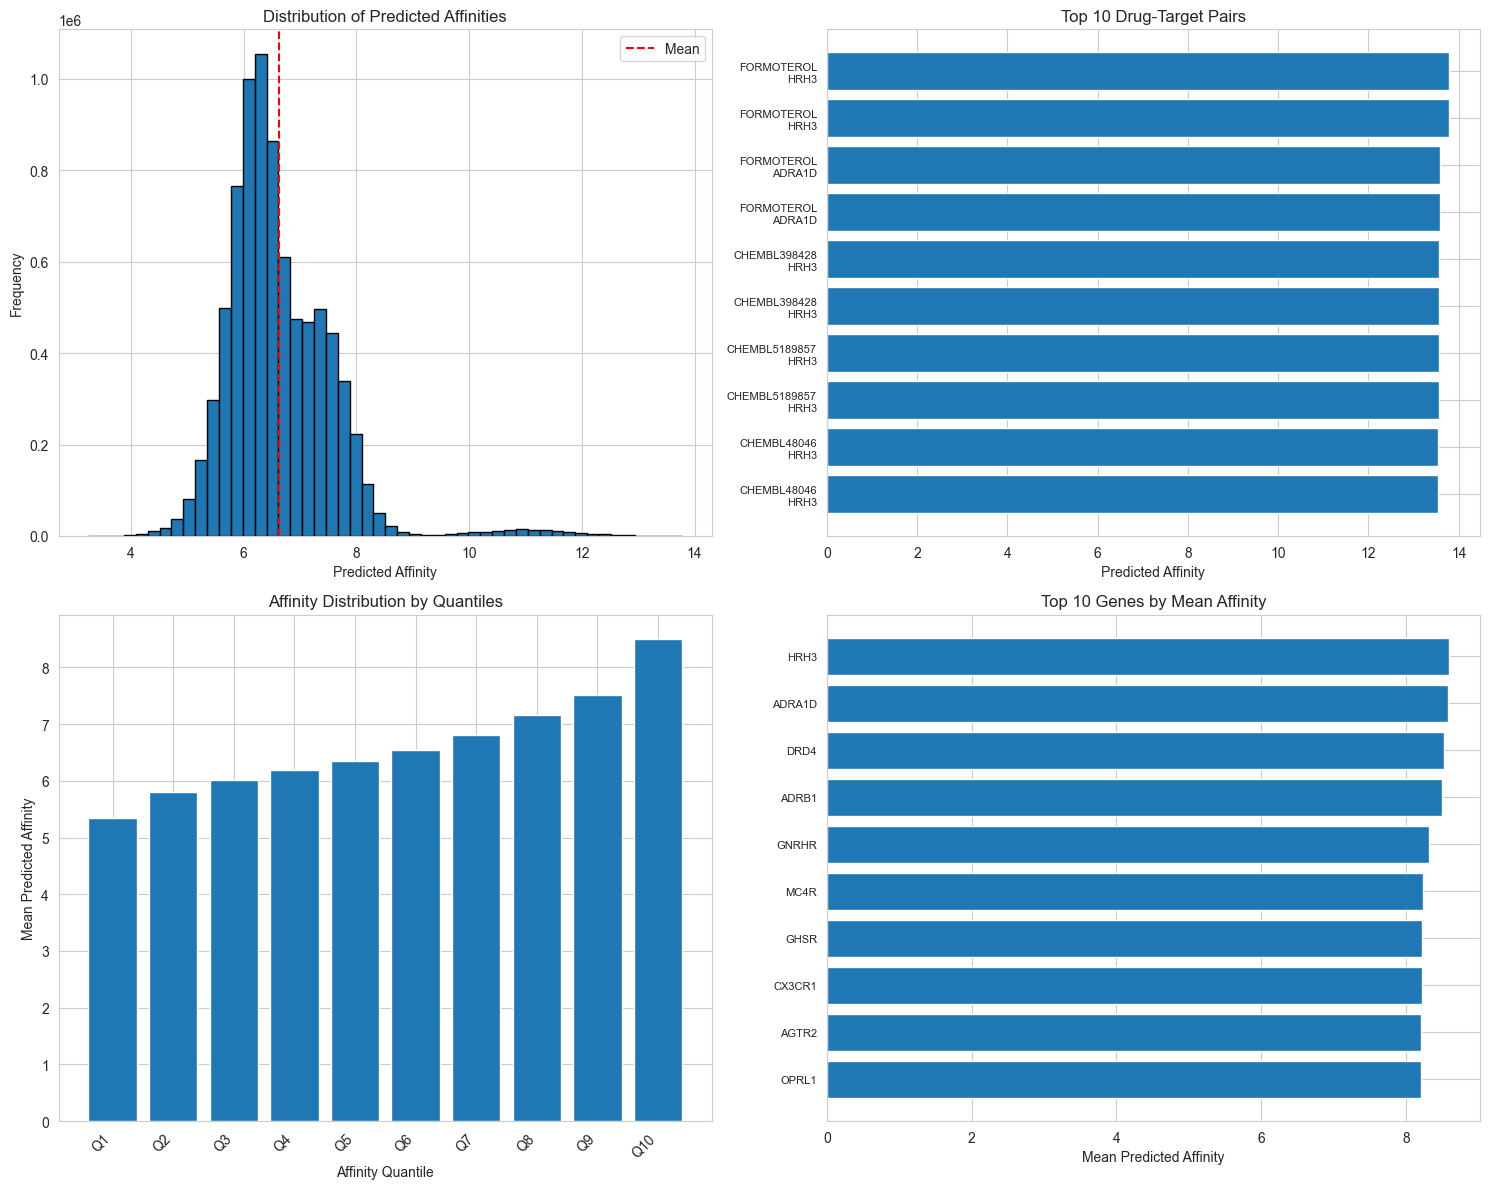

In [53]:
# Example 6: Visualize predictions
if agent.predictions_df is not None:
    agent.visualize_predictions(top_n=100)
else:
    print("⚠️  No predictions available for visualization.")

In [54]:
# Example 7: Export results
if agent.predictions_df is not None:
    agent.export_results(top_n=100, min_affinity=None)
else:
    print("⚠️  No predictions to export.")

✅ Results exported to: parkinsons_drug_discovery_results_20260111_174142.csv
  Total rows: 100


## 🎯 Complete Discovery Workflow

In [55]:
# Complete workflow: Discover new drug candidates
def discover_drug_candidates(min_priority=0.7, top_n=50, exclude_known=True):
    """Complete workflow for drug discovery."""
    print("🔬 Starting Drug Discovery Workflow...")
    print("="*60)
    
    # 1. Get high-priority targets
    print("\n📊 Step 1: Identifying high-priority targets...")
    high_priority = agent.get_high_priority_targets(min_priority=min_priority)
    if high_priority is None or len(high_priority) == 0:
        print("❌ No high-priority targets found.")
        return
    
    print(f"  ✅ Found {len(high_priority)} high-priority targets")
    print(f"  Top genes: {', '.join(high_priority['Gene'].head(10).tolist())}")
    
    # 2. Get drug-target combinations
    print("\n🔗 Step 2: Generating drug-target combinations...")
    combinations = agent.get_drug_target_combinations(min_priority=min_priority)
    if len(combinations) == 0:
        print("❌ No combinations generated.")
        return
    
    print(f"  ✅ Generated {len(combinations)} drug-target pairs")
    
    # 3. Filter by known interactions if requested
    if exclude_known and 'known_interaction' in combinations.columns:
        novel = combinations[combinations['known_interaction'] == False]
        print(f"  📝 Novel interactions (excluding known): {len(novel)}")
        combinations = novel
    
    # 4. If predictions available, rank by affinity
    if agent.predictions_df is not None and 'Predicted_Affinity' in agent.predictions_df.columns:
        print("\n🎯 Step 3: Ranking by predicted affinity...")
        # Merge predictions
        if 'Chem ID' in combinations.columns and 'targetId' in combinations.columns:
            merged = combinations.merge(
                agent.predictions_df[['Chem ID', 'targetId', 'Predicted_Affinity']],
                on=['Chem ID', 'targetId'],
                how='left'
            )
            merged = merged.sort_values('Predicted_Affinity', ascending=False, na_last=True)
            combinations = merged
            print(f"  ✅ Ranked {len(combinations)} candidates")
    
    # 5. Display top candidates
    print(f"\n🏆 Step 4: Top {top_n} candidates:")
    print("="*60)
    
    display_cols = []
    for col in ['Drug Name', 'Gene', 'Predicted_Affinity', 'priority', 'score', 
               'isApproved', 'maximumClinicalTrialPhase', 'Chem ID']:
        if col in combinations.columns:
            display_cols.append(col)
    
    top_candidates = combinations.head(top_n)
    if len(display_cols) > 0:
        print(top_candidates[display_cols].to_string())
    
    return top_candidates


# Run the discovery workflow
# Uncomment to execute:
# candidates = discover_drug_candidates(min_priority=0.7, top_n=50, exclude_known=True)

## 🤖 LLM-Powered Analysis

Use OpenAI to analyze queries and generate intelligent summaries about drug candidates.

In [56]:
# Setup: Initialize agent with OpenAI API key
# Option 1: Set environment variable (recommended)
# import os
# os.environ['OPENAI_API_KEY'] = 'your-api-key-here'

# Option 2: Pass API key directly (less secure)
# agent = ParkinsonsDrugDiscoveryAgent(data_dir="./", openai_api_key="your-api-key-here")

# Check if LLM is available
if agent.openai_client is not None:
    print("✅ LLM features are enabled!")
else:
    print("⚠️  LLM features are disabled. Set OPENAI_API_KEY to enable.")

✅ LLM features are enabled!


In [57]:
# Example 8: Analyze a user query with LLM
# This will understand the query, analyze relevant data, and search online for additional context

if agent.openai_client is not None:
    # Get top candidates for context
    top_candidates = agent.get_top_candidates(top_n=20, exclude_known=True)
    
    # Ask a question about the data
    user_query = "What are the most promising drug candidates for Parkinson's disease based on binding affinity?"
    
    # Analyze with LLM
    analysis = agent.analyze_with_llm(
        user_query=user_query,
        context_data=top_candidates,
        include_online_search=True,
        model="gpt-4o-mini"  # or "gpt-4", "gpt-3.5-turbo"
    )
    
    print("\n" + "="*60)
    print("🤖 LLM Analysis Results:")
    print("="*60)
    print(analysis)
else:
    print("⚠️  OpenAI client not initialized. Please set OPENAI_API_KEY.")

🏆 Top 20 candidates:
🤖 Analyzing query with LLM (gpt-4o-mini)...
🌐 Searching online for additional information...
✅ Analysis completed!

🤖 LLM Analysis Results:
### Comprehensive Analysis of Promising Drug Candidates for Parkinson's Disease

#### Key Findings from the Data:
- The dataset comprises a total of **8,194,607 predictions**, with a **mean binding affinity** of **6.6237** across all entries.
- The subset of **20 records** shows a significantly higher **mean affinity** of **13.5540**, indicating that these candidates may have a stronger interaction potential with their targets.
- The **binding affinities** for the top candidates range from **13.4751** to **13.7812**, highlighting a narrow but promising range of high-affinity interactions.

#### Most Promising Drug Candidates:
1. **Formoterol**
   - **Target:** Histamine Receptor H3 (HRH3)
   - **Affinity:** 13.7812
   - **Notes:** Formoterol is a known bronchodilator; its potential application in Parkinson's disease could invol

In [58]:
# Example 9: Generate comprehensive summary of prioritized drug candidates
# This combines data analysis with online research to create a detailed report

if agent.openai_client is not None:
    summary = agent.generate_drug_candidate_summary(
        top_n=20,
        min_affinity=None,  # or set a threshold like 7.0
        include_online_research=True,
        model="gpt-4o-mini"
    )
    
    print("\n" + "="*60)
    print("📊 Comprehensive Drug Candidate Summary:")
    print("="*60)
    print(summary)
    
    # Optionally save the summary
    # with open('drug_candidate_summary.txt', 'w') as f:
    #     f.write(summary)
else:
    print("⚠️  OpenAI client not initialized. Please set OPENAI_API_KEY.")

🏆 Top 20 candidates:
📊 Generating summary for 20 drug candidates...
🌐 Researching top candidates online...
✅ Summary generated!

📊 Comprehensive Drug Candidate Summary:
# Comprehensive Summary Report on Drug Candidates for Parkinson's Disease

## Executive Summary
This report evaluates prioritized drug candidates for Parkinson's disease based on binding affinity predictions and target prioritization data. The analysis identifies **Formoterol** as the most promising candidate, exhibiting high binding affinity to the **HRH3** and **ADRA1D** targets. The data indicates a strong correlation between predicted binding affinity and disease relevance, particularly for HRH3, highlighting its potential role in therapeutic strategies. Key findings include:

- **Formoterol** is currently approved and in Phase 4 trials, demonstrating established safety and efficacy profiles.
- Several compounds targeting **HRH3** show promising predicted affinities, with potential implications for symptom managemen

In [59]:
# Example 10: Ask specific questions about targets or drugs
# The LLM will analyze the data and provide insights

if agent.openai_client is not None:
    # Example queries you can ask:
    queries = [
        "Which targets have the highest priority scores and what does this mean for Parkinson's disease?",
        "Are there any FDA-approved drugs that show high binding affinity to high-priority targets?",
        "What are the clinical trial phases of the top drug candidates?",
        "Compare the binding affinities of approved vs non-approved drugs for Parkinson's disease targets"
    ]
    
    # Select a query to analyze
    selected_query = queries[0]  # Change index to try different queries
    
    # Get relevant data
    high_priority_targets = agent.get_high_priority_targets(min_priority=0.8)
    if high_priority_targets is not None:
        # Merge with predictions if available
        if agent.predictions_df is not None and 'targetId' in agent.predictions_df.columns:
            relevant_data = agent.predictions_df[
                agent.predictions_df['targetId'].isin(high_priority_targets['targetId'])
            ].head(50)
        else:
            relevant_data = high_priority_targets
    else:
        relevant_data = agent.get_top_candidates(top_n=20)
    
    # Analyze with LLM
    analysis = agent.analyze_with_llm(
        user_query=selected_query,
        context_data=relevant_data,
        include_online_search=True
    )
    
    print(f"\n📝 Query: {selected_query}")
    print("\n" + "="*60)
    print("🤖 Analysis:")
    print("="*60)
    print(analysis)
else:
    print("⚠️  OpenAI client not initialized. Please set OPENAI_API_KEY.")

🎯 Found 168 high-priority targets (priority >= 0.8)
🤖 Analyzing query with LLM (gpt-4o-mini)...
🌐 Searching online for additional information...
✅ Analysis completed!

📝 Query: Which targets have the highest priority scores and what does this mean for Parkinson's disease?

🤖 Analysis:
## Comprehensive Analysis of Drug-Target Interaction Data for Parkinson's Disease

### Key Findings from the Data
The dataset comprises a total of 8,194,607 predictions, with a particular focus on 50 records that exhibit a significantly higher mean affinity of 13.1202, compared to the overall mean of 6.6237. This indicates that the selected candidates are likely to have strong binding interactions with their respective targets.

### Most Promising Drug Candidates
The top drug candidates based on binding affinity to the dopamine receptor D4 (DRD4) are as follows:

1. **FORMOTEROL** 
   - **Target**: DRD4
   - **Affinity**: 13.4112 (appears twice)
   
2. **CHEMBL258467**
   - **Target**: DRD4
   - **Affinit

## 📝 LLM Features Summary

The LLM-powered analysis module provides:

1. **`analyze_with_llm()`**: Understands natural language queries and provides intelligent analysis
   - Analyzes user questions about the data
   - Integrates context from selected dataframes
   - Searches online for additional information
   - Generates comprehensive insights

2. **`generate_drug_candidate_summary()`**: Creates detailed reports about prioritized candidates
   - Analyzes top drug-target pairs
   - Integrates online research
   - Provides structured summaries with recommendations

3. **`search_online_info()`**: Searches public resources for additional context
   - Uses DuckDuckGo API (free, no API key needed)
   - Retrieves relevant scientific information
   - Integrates findings into LLM analysis

### Setup Instructions:

1. Install required packages:
   ```bash
   pip install openai requests
   ```

2. Set your OpenAI API key:
   ```python
   import os
   os.environ['OPENAI_API_KEY'] = 'your-api-key-here'
   ```
   Or pass it when initializing:
   ```python
   agent = ParkinsonsDrugDiscoveryAgent(data_dir="./", openai_api_key="your-key")
   ```

3. Use the LLM features as shown in the examples above!

## Summary

This AI agent provides a comprehensive toolkit for Parkinson's disease drug discovery with:

1. **Data Management**: Load and manage drug, target, and interaction data
2. **Smart Search**: Find drugs and targets by multiple criteria
3. **Priority Analysis**: Identify high-priority targets based on disease relevance
4. **Binding Affinity Analysis**: Analyze pre-computed binding affinity predictions from CSV
5. **Recommendations**: Get top candidates ranked by predicted affinity
6. **Visualization**: Create informative plots and analysis
7. **Export**: Save results for further analysis
8. **🤖 LLM-Powered Analysis**: Use OpenAI to understand queries and generate intelligent summaries
9. **🌐 Online Research**: Combine data with public resources for comprehensive analysis

### Key Features:
- Uses pre-computed predictions from `pkd_drug_candidates_predictions.csv`
- No ML model loading required - all predictions are read from CSV
- Fast analysis and filtering of existing predictions
- Interactive search and exploration capabilities
- **NEW**: Natural language query understanding with OpenAI
- **NEW**: Automatic online research integration
- **NEW**: Comprehensive summary generation for drug candidates

### LLM Features:
- **Natural Language Queries**: Ask questions in plain English about your data
- **Intelligent Analysis**: Get AI-powered insights about drug candidates
- **Online Research Integration**: Automatically search and integrate public resources
- **Comprehensive Summaries**: Generate detailed reports about prioritized candidates